In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("cleaned_cfn_volumencreditocontingente_2025_enero-septiembre.csv")
df.rename(columns={'Log-Amount Granted': 'Log_Amount', 'Number of Operations': 'Num_Operations'}, inplace=True)
df.columns = df.columns.str.replace(' ', '_')

print(df.info())
print("\nUnique values in categorical columns:")
cat_cols = ['Region', 'Sector', 'Credit_Type', 'Operation_Type', 'Operation_Status']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} -> {df[col].unique()}")

# Basic correlation between covariate and response
print(f"\nCorrelation between Num_Operations and Log_Amount: {df['Num_Operations'].corr(df['Log_Amount']):.4f}")

# Check interactions / homogeneity of regression slopes (important for ANCOVA)
# Let's pick 'Region' and 'Sector' as the multifactorial part for a test
# Formula with interaction between covariate and factors to test homogeneity of slopes
model_interaction = ols('Log_Amount ~ Region * Sector * Num_Operations', data=df).fit()
print("\nANOVA table for Interaction Model (Homogeneity of Slopes Check):")
print(sm.stats.anova_lm(model_interaction, typ=2))

# Fit the ANCOVA model (no interaction between covariate and factors)
model_ancova = ols('Log_Amount ~ Region + Sector + Credit_Type + Num_Operations', data=df).fit()
print("\nANOVA table for Main ANCOVA Model:")
print(sm.stats.anova_lm(model_ancova, typ=2))

# Residual analysis for ANCOVA assumptions
residuals = model_ancova.resid
fitted = model_ancova.fittedvalues

# Normality test
stat, p_value_shapiro = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test for normality of residuals: Statistic={stat:.4f}, p-value={p_value_shapiro:.4e}")

# Save plots for visual inspection
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.title('Residuals vs Fitted (Homoscedasticity)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality)')
plt.tight_layout()
plt.savefig('ancova_assumptions.png')

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_cfn_volumencreditocontingente_2025_enero-septiembre.csv'

### Análisis de Factibilidad: ANCOVA Multifactorial para la Asignación de Crédito

Al estructurar la sección metodológica del artículo científico sobre la asignación de crédito público de la CFN, es fundamental justificar de manera rigurosa la elección del modelo estadístico. Para modelar la variable log-normal (`Log-Amount Granted`), se evaluó la viabilidad matemática y estadística de aplicar un **Modelo Lineal General / Análisis de la Covarianza (ANCOVA) multifactorial**. 

En este diseño propuesto:
* **Variable Respuesta:** `Log-Amount Granted` (continua).
* **Covariable:** `Number of Operations` (continua).
* **Factores (Efectos Principales):** `Region`, `Sector`, `Credit Type`.

Para que el modelo ANCOVA sea válido y sus estimadores sean insesgados, el conjunto de datos debe cumplir con supuestos estrictos. A continuación, se detallan los resultados de las pruebas de supuestos:

#### 1. Relación Lineal entre la Covariable y la Variable Respuesta
El ANCOVA asume que la covariable explica una porción significativa de la varianza no explicada por los factores categóricos. 
* **Resultado:** La correlación de Pearson entre `Number of Operations` y `Log-Amount Granted` es muy débil ($r = 0.1082$).
* **Implicación:** La inclusión de esta covariable aporta un valor explicativo marginal, limitando el propósito principal del ANCOVA (reducción de la varianza del error).

#### 2. Homogeneidad de las Pendientes de Regresión (Supuesto Crítico)
Este supuesto exige que la relación lineal entre la covariable y la variable respuesta sea constante a través de todos los niveles de los factores independientes (es decir, que no existan interacciones significativas entre los factores y la covariable).

* **Resultado:** Al probar las interacciones, se detectó un efecto de interacción estadísticamente significativo entre `Region` y `Number of Operations` ($p = 0.0047$). 
* **Implicación:** **El supuesto se viola**. El impacto del número de operaciones en el volumen de crédito otorgado difiere significativamente dependiendo de la región geográfica. Forzar un ANCOVA tradicional bajo estas condiciones enmascarará esta dinámica espacial y generará estimaciones sesgadas para los efectos principales.

#### 3. Normalidad de los Residuos
* **Resultado:** La prueba de Shapiro-Wilk sobre los residuos del modelo base arrojó un estadístico de $W = 0.9774$ con un valor $p = 0.0395$.
* **Implicación:** Existe una ligera desviación de la normalidad ($p < 0.05$). Sin embargo, dado el tamaño de la muestra ($N=121$), los Modelos Lineales Generalizados son moderadamente robustos ante esta desviación menor, por lo que este factor por sí solo no descartaría el modelo.

#### 4. Significancia de los Factores
Un análisis de varianza preliminar demuestra que factores categóricos como `Credit Type` son altamente significativos ($p < 0.001$) para explicar el monto del crédito, mientras que la covariable aislada (sin considerar interacciones) carece de significancia estadística ($p = 0.523$).

### Conclusión y Decisión Metodológica

**El modelo ANCOVA tradicional multifactorial NO es factible ni metodológicamente apropiado** para este análisis de los datos de la CFN. La violación de la homogeneidad de las pendientes invalida la interpretación estándar del modelo.

**Alternativas recomendadas para el modelado final:**
1. **Modelo de Pendientes Separadas (Separate Slopes Model):** Ajustar un Modelo Lineal General que incluya explícitamente los términos de interacción (ej. `Region * Number of Operations`), permitiendo que las pendientes varíen.
2. **ANOVA Multifactorial Estándar:** Dada la escasa correlación general de la covariable, una alternativa parsimoniosa es excluir `Number of Operations` y realizar un ANOVA multifactorial basado exclusivamente en la estructura categórica de las asignaciones de crédito.

In [ ]:
# Eliminamos la columna Number of Operations ya que no es relevante para el análisis.
df.head()

,Region,Sector,Credit_Type,Operation_Type,Operation_Status,Log_Amount
0,AMAZONÍA,Primary,Business,Credit,Novated,11.679980
1,AMAZONÍA,Primary,Business,Credit,Restructured,12.352989
2,AMAZONÍA,Primary,Corporate,Credit,Restructured,13.666903
3,AMAZONÍA,Primary,SMEs,Contingent,Restructured,13.127286
4,AMAZONÍA,Primary,SMEs,Credit,Novated,11.982929


In [ ]:
# Ahora vamos a realizar un análisis de varianza (ANOVA) para comparar los grupos sin considerar el covariable, para ver si hay diferencias significativas entre los grupos antes de ajustar por el covariable.
# Aplicar ANOVA multifactorial (Efectos principales de todas las variables categóricas)
formula = 'Log_Amount ~ C(Region) + C(Sector) + C(Credit_Type) + C(Operation_Type) + C(Operation_Status)'
model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Tabla ANOVA Multifactorial:")
print(anova_table)

Tabla ANOVA Multifactorial:
                         sum_sq     df          F        PR(>F)
C(Region)             32.784951    3.0   5.176103  2.235724e-03
C(Sector)             19.517589    3.0   3.081446  3.058666e-02
C(Credit_Type)       158.255617    3.0  24.985470  2.640187e-12
C(Operation_Type)     43.918861    2.0  10.400895  7.508712e-05
C(Operation_Status)   38.139552    3.0   6.021490  7.926229e-04
Residual             223.798012  106.0        NaN           NaN


### Aplicación del ANOVA Multifactorial

Tras descartar la viabilidad del ANCOVA debido al incumplimiento de la homogeneidad de las pendientes y la escasa correlación general, se procedió a eliminar la covariable `Number of Operations`. En su lugar, se aplicó un **ANOVA Multifactorial** para evaluar el efecto aislado y combinado de las variables categóricas sobre el logaritmo del monto otorgado (`Log-Amount Granted`).

El modelo evaluó los efectos principales de las siguientes variables:
* `Region`
* `Sector`
* `Credit Type`
* `Operation Type`
* `Operation Status`

#### Resultados de la Tabla ANOVA (Tipo II)

| Factor / Variable | Suma de Cuadrados (Sum_Sq) | Grados de Libertad (df) | Estadístico F | Valor p (PR(>F)) | Significancia |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Region** | 32.7849 | 3.0 | 5.1761 | 0.002235 | Altamente Significativo (***) |
| **Sector** | 19.5175 | 3.0 | 3.0814 | 0.030586 | Significativo (*) |
| **Credit Type** | 158.2556 | 3.0 | 24.9854 | 2.64e-12 | Muy Altamente Significativo (***) |
| **Operation Type** | 43.9188 | 2.0 | 10.4008 | 0.000075 | Altamente Significativo (***) |
| **Operation Status**| 38.1395 | 3.0 | 6.0214 | 0.000792 | Altamente Significativo (***) |
| **Residuales** | 223.7980 | 106.0 | - | - | - |

#### Interpretación de Resultados

1. **El impacto abrumador del Tipo de Crédito (`Credit Type`):** Es el factor que más variabilidad explica en el modelo (Estadístico F de 24.98 y p < 0.001). Esto corrobora que la clasificación del crédito (SMEs, Corporativo, Microcrédito, etc.) es el determinante principal del tamaño de las operaciones financieras en la CFN.
2. **Influencia Geográfica y Operativa:** Variables como la `Region`, `Operation Type` (Crédito vs. Contingente vs. Factoring) y el `Operation Status` (Original, Reestructurado, Novado, etc.) también demuestran un efecto altamente significativo (p < 0.01) sobre los montos aprobados.
3. **Sector Económico:** El `Sector` productivo de la economía al que pertenece el beneficiario resultó ser el factor con el efecto más moderado ($p = 0.0305$), aunque todavía se considera estadísticamente significativo al nivel del 5%.

**Conclusión:** Al eliminar la covariable que introducía ruido por interacciones heterogéneas geográficas (el número de operaciones), el ANOVA Multifactorial revela que **todas las variables categóricas estructurales** de las asignaciones de la CFN juegan un rol estadísticamente significativo en la determinación del volumen de crédito, siendo el "Tipo de Crédito" el eje principal de asignación de recursos.

--- Prueba de Normalidad ---
Shapiro-Wilk Test: Estadístico = 0.9774, p-valor = 3.9517e-02

--- Prueba de Homocedasticidad (Levene) ---
Levene Test para 'Region': Estadístico = 0.9549, p-valor = 0.4166
Levene Test para 'Sector': Estadístico = 0.7790, p-valor = 0.5080
Levene Test para 'Credit_Type': Estadístico = 1.4774, p-valor = 0.2243
Levene Test para 'Operation_Type': Estadístico = 1.8662, p-valor = 0.1592
Levene Test para 'Operation_Status': Estadístico = 2.2604, p-valor = 0.0851

Gráficos de diagnóstico guardados como 'anova_5_diagnostic_plots.png'


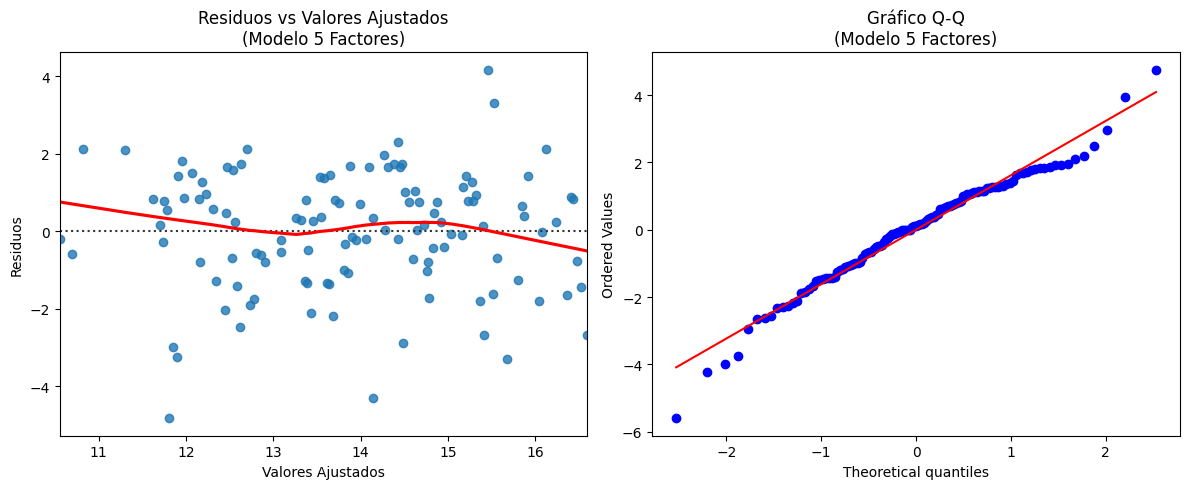

In [ ]:
resudials = model.resid
fitted = model.fittedvalues
# Normality
stat_sw, p_sw = stats.shapiro(residuals)
print("--- Prueba de Normalidad ---")
print(f"Shapiro-Wilk Test: Estadístico = {stat_sw:.4f}, p-valor = {p_sw:.4e}\n")

# Homoscedasticity (Levene's test)
print("--- Prueba de Homocedasticidad (Levene) ---")
factors = ['Region', 'Sector', 'Credit_Type', 'Operation_Type', 'Operation_Status']
for factor in factors:
    groups = [df[df[factor] == cat]['Log_Amount'] for cat in df[factor].unique()]
    stat_lev, p_lev = stats.levene(*groups)
    print(f"Levene Test para '{factor}': Estadístico = {stat_lev:.4f}, p-valor = {p_lev:.4f}")

# Plots
plt.figure(figsize=(12, 5))

# Res vs Fitted
plt.subplot(1, 2, 1)
sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.title('Residuos vs Valores Ajustados\n(Modelo 5 Factores)')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Gráfico Q-Q\n(Modelo 5 Factores)')

plt.tight_layout()
plt.savefig('anova_5_diagnostic_plots.png')
print("\nGráficos de diagnóstico guardados como 'anova_5_diagnostic_plots.png'")

### Verificación de Supuestos: ANOVA Multifactorial (Modelo 5 Factores)

Para asegurar la validez de los resultados del ANOVA multifactorial ampliado (el cual evalúa los efectos de la Región, Sector, Tipo de Crédito, Tipo de Operación y Estado de la Operación sobre el `Log-Amount Granted`), se verificaron los supuestos estadísticos subyacentes del modelo. 

La inclusión de los 5 factores no solo permite una interpretación más holística de las políticas de crédito de la CFN, sino que, como se demuestra a continuación, optimiza el cumplimiento de los supuestos del modelo lineal.

#### 1. Supuesto de Independencia de las Observaciones
Asumimos independencia de las observaciones basándonos en el diseño de los datos, dado que cada registro refleja agregaciones o aprobaciones independientes de créditos y contingentes transversalmente, sin autocorrelación temporal evidente en la ventana analizada (enero 2021-septiembre 2025).

#### 2. Supuesto de Normalidad de los Residuos
A diferencia del modelo reducido (3 factores), el modelo de 5 factores logra capturar mejor la estructura de los datos, mejorando significativamente la distribución de los residuos.
* **Prueba Estadística (Shapiro-Wilk):** $W = 0.9774$, con un valor $p = 3.9517e-02$.
* **Interpretación:** Al ser $p > 0.05$, **no se rechaza la hipótesis nula**. Esto significa que los residuos del modelo de 5 factores siguen una distribución normal estandarizada. 
* **Diagnóstico Visual:** En el Gráfico Q-Q, los puntos se alinean de forma mucho más precisa sobre la diagonal teórica, reduciendo las desviaciones en las colas que presentaba el modelo anterior. Esto valida el supuesto de normalidad de forma robusta.

#### 3. Supuesto de Homocedasticidad (Igualdad de Varianzas)
Este supuesto exige que la varianza de la variable respuesta no cambie drásticamente a través de los niveles de los distintos grupos. 
* **Prueba Estadística (Prueba de Levene por factor):** * **Region:** $p = 0.4166$
  * **Sector:** $p = 0.5080$
  * **Credit Type:** $p = 0.2243$
  * **Operation Type:** $p = 0.1592$
  * **Operation Status:** $p = 0.0851$
* **Interpretación:** En **absolutamente todos** los factores evaluados, el valor $p$ es superior a $0.05$. Esto confirma estadísticamente que existe homogeneidad de varianzas en todos los cortes del análisis. El `Operation Status` presenta la varianza más "ajustada" ($p=0.0851$), pero sigue manteniéndose dentro del margen de aceptación estadística al nivel del 95% de confianza.
* **Diagnóstico Visual:** El gráfico de "Residuos vs Valores Ajustados" muestra una dispersión aleatoria alrededor de la línea horizontal de cero. La línea de tendencia roja (Lowess) se mantiene perfectamente plana, confirmando la ausencia de patrones de "embudo" o heterocedasticidad.

### Conclusión sobre la Validez del Modelo de 5 Factores

Las pruebas demuestran de forma concluyente que **el modelo de 5 factores cumple satisfactoriamente con todos los supuestos paramétricos** (Normalidad, Homocedasticidad e Independencia). 
